# SoccerNet SynLoc — Kaggle
Challenge: Spiideo SoccerNet SynLoc 2026

## Rutas y verificación

In [25]:
import os, sys, torch

MODEL_PATH  = './yoloxpose_tiny_4xb64-300e_640_epoch_300.pth'  # ya está en el explorador
IMAGES_DIR  = './mini'                                           # ya está en el explorador
ANN_PATH    = './annotations.zip'                                # ya está en el explorador
WORK_DIR    = './working'
CONFIG_PATH = os.path.join(WORK_DIR, 'configs/body_bev_position/spiideo_soccernet/yoloxpose_tiny_4xb64-300e_640.py')

print('Python:', sys.version)
print('PyTorch:', torch.__version__)
print('CUDA:', torch.version.cuda)
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')
print('Modelo existe:', os.path.exists(MODEL_PATH))
print('Imagenes existe:', os.path.exists(IMAGES_DIR))
print('Anotaciones existe:', os.path.exists(ANN_PATH))
print('Config existe:', os.path.exists(CONFIG_PATH))

Python: 3.11.14 (main, Feb 12 2026, 00:42:50) [Clang 21.1.4 ]
PyTorch: 2.1.0+cpu
CUDA: None
GPU: No GPU
Modelo existe: True
Imagenes existe: True
Anotaciones existe: True
Config existe: True


In [26]:
import torch
import mmcv
import mmengine
import mmdet
import mmpose
import sskit

print('torch:', torch.__version__)
print('mmcv:', mmcv.__version__)
print('mmengine:', mmengine.__version__)
print('mmdet:', mmdet.__version__)
print('mmpose:', mmpose.__version__)
print('sskit OK')
print('Todo bien ✓')

torch: 2.1.0+cpu
mmcv: 2.1.0
mmengine: 0.10.7
mmdet: 3.3.0
mmpose: 1.3.2
sskit OK
Todo bien ✓


## Paso 2 — Descargar configs del modelo

In [ ]:
import os
import urllib.request

base = 'https://raw.githubusercontent.com/Spiideo/mmpose/spiideo_scenes/configs'
WORK_DIR = os.path.join(os.getcwd(), 'working')

os.makedirs(f'{WORK_DIR}/configs/body_2d_keypoint/yoloxpose/coco', exist_ok=True)
os.makedirs(f'{WORK_DIR}/configs/body_bev_position/spiideo_soccernet', exist_ok=True)
os.makedirs(f'{WORK_DIR}/configs/_base_/datasets', exist_ok=True)

archivos = [
    (f'{base}/body_2d_keypoint/yoloxpose/coco/yoloxpose_tiny_4xb64-300e_coco-640.py',
     f'{WORK_DIR}/configs/body_2d_keypoint/yoloxpose/coco/yoloxpose_tiny_4xb64-300e_coco-640.py'),
    (f'{base}/body_2d_keypoint/yoloxpose/coco/yoloxpose_s_8xb32-300e_coco-640.py',
     f'{WORK_DIR}/configs/body_2d_keypoint/yoloxpose/coco/yoloxpose_s_8xb32-300e_coco-640.py'),
    (f'{base}/body_bev_position/spiideo_soccernet/synloc.py',
     f'{WORK_DIR}/configs/body_bev_position/spiideo_soccernet/synloc.py'),
    (f'{base}/body_bev_position/spiideo_soccernet/yoloxpose_tiny_4xb64-300e_640.py',
     f'{WORK_DIR}/configs/body_bev_position/spiideo_soccernet/yoloxpose_tiny_4xb64-300e_640.py'),
    (f'{base}/_base_/default_runtime.py',
     f'{WORK_DIR}/configs/_base_/default_runtime.py'),
    (f'{base}/_base_/datasets/spiideo_soccernet_synloc.py',
     f'{WORK_DIR}/configs/_base_/datasets/spiideo_soccernet_synloc.py'),
]

for url, dest in archivos:
    try:
        urllib.request.urlretrieve(url, dest)
        print(f'✅ {os.path.basename(dest)}')
    except Exception as e:
        print(f'❌ {os.path.basename(dest)}: {e}')

link_path = './configs'
target_path = f'{WORK_DIR}/configs'
if os.path.islink(link_path) or os.path.exists(link_path):
    print('✅ ./configs ya existe')
else:
    os.symlink(target_path, link_path)
    print(f'✅ symlink creado: {link_path} -> {target_path}')

✅ yoloxpose_tiny_4xb64-300e_coco-640.py
✅ yoloxpose_s_8xb32-300e_coco-640.py
✅ synloc.py
✅ yoloxpose_tiny_4xb64-300e_640.py
✅ default_runtime.py
✅ spiideo_soccernet_synloc.py
✅ ./configs ya existe


## Paso 3 — Cargar el modelo baseline

In [28]:
import torch
import numpy as np

# Parchear torch.load para compatibilidad con PyTorch 2.6+
# Solo se aplica una vez aunque se corra la celda varias veces
if not getattr(torch.load, '_patched', False):
    _original_torch_load = torch.load
    def patched_torch_load(f, *args, **kwargs):
        kwargs['weights_only'] = False
        return _original_torch_load(f, *args, **kwargs)
    patched_torch_load._patched = True
    torch.load = patched_torch_load
    print('✅ torch.load parcheado')
else:
    print('✅ torch.load ya estaba parcheado')

from mmpose.apis import init_model, inference_topdown

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando: {device}')

model = init_model(CONFIG_PATH, MODEL_PATH, device=device)
print('✅ Modelo cargado')

✅ torch.load ya estaba parcheado
Usando: cpu


Loads checkpoint by local backend from path: ./yoloxpose_tiny_4xb64-300e_640_epoch_300.pth
✅ Modelo cargado


## Paso 4 — Inferencia en una imagen

In [29]:
from sskit import normalize, image_to_ground
from PIL import Image
import numpy as np
import json
import zipfile


def load_annotations(ann_path, work_dir):
    if ann_path.endswith('.zip'):
        with zipfile.ZipFile(ann_path, 'r') as zf:
            json_candidates = [
                'annotations/mini.json',
                'annotations/challenge_public.json',
                'annotations/val.json',
                'annotations/test.json',
                'annotations/train.json',
            ]
            ann_member = next((p for p in json_candidates if p in zf.namelist()), None)
            if ann_member is None:
                raise FileNotFoundError('No se encontró ningún JSON de anotaciones dentro del zip')
            with zf.open(ann_member) as f:
                annotations_data = json.load(f)

        ann_json_path = f'{work_dir}/annotations_loaded.json'
        with open(ann_json_path, 'w') as f:
            json.dump(annotations_data, f)

        print(f'✅ Anotaciones cargadas desde ZIP: {ann_member}')
        print(f'✅ Copia JSON para COCO: {ann_json_path}')
        return annotations_data, ann_json_path

    with open(ann_path, 'r') as f:
        annotations_data = json.load(f)
    return annotations_data, ann_path


def get_pitch_range(annotations_data):
    posiciones = [a['position_on_pitch'] for a in annotations_data['annotations']]
    xs = [p[0] for p in posiciones]
    ys = [p[1] for p in posiciones]
    return min(xs), max(xs), min(ys), max(ys)


def prepare_image_inputs(img_info, images_dir):
    image_path = os.path.join(images_dir, os.path.basename(img_info['file_name']))
    camera_matrix = np.array(img_info['camera_matrix'], dtype=np.float32)
    dist_poly = np.array(img_info['dist_poly'], dtype=np.float32)
    image_np = np.array(Image.open(image_path))
    sskit_shape = (image_np.shape[2], image_np.shape[0], image_np.shape[1])  # (canales, alto, ancho)
    return image_path, camera_matrix, dist_poly, image_np, sskit_shape


# 1) Cargar anotaciones
annotations, ANN_JSON_PATH = load_annotations(ANN_PATH, WORK_DIR)

# 2) Resumen del dataset
x_min, x_max, y_min, y_max = get_pitch_range(annotations)
print(f'Rango real del campo — X: min={x_min:.2f}m, max={x_max:.2f}m')
print(f'Rango real del campo — Y: min={y_min:.2f}m, max={y_max:.2f}m')

# 3) Preparar la primera imagen para inferencia
model.test_cfg['score_thr'] = 0.01
img_info = annotations['images'][0]
img_path, cam_mat, dist_p, img_np, shape_sskit = prepare_image_inputs(img_info, IMAGES_DIR)

# 4) Inferencia de ejemplo en una imagen
results = inference_topdown(model, img_path)
result = results[0]
keypoints = result.pred_instances.keypoints
scores = result.pred_instances.scores

print(f'\nTotal detecciones: {len(scores)}')
for i in range(len(scores)):
    bbox_score = float(scores[i])
    pie_norm = normalize(keypoints[i][1], shape_sskit).float()
    try:
        pos = image_to_ground(cam_mat, dist_p, pie_norm)
        print(f'  Jugador {i+1:2d}: ({pos[0]:6.2f}m, {pos[1]:6.2f}m) score:{bbox_score:.3f}')
    except Exception as e:
        print(f'  Jugador {i+1:2d}: error — {e}')

✅ Anotaciones cargadas desde ZIP: annotations/mini.json
✅ Copia JSON para COCO: /home/willi/Documentos/Hands on CV/soccernet_2/working/annotations_loaded.json
Rango real del campo — X: min=-34.17m, max=34.88m
Rango real del campo — Y: min=-54.64m, max=53.89m

Total detecciones: 32
  Jugador  1: (-16.45m,  33.10m) score:0.984
  Jugador  2: (-27.78m,  23.46m) score:0.981
  Jugador  3: ( -6.75m,  17.52m) score:0.977
  Jugador  4: ( -9.50m,  25.02m) score:0.977
  Jugador  5: ( -5.72m,  23.35m) score:0.972
  Jugador  6: ( -6.62m,  20.97m) score:0.971
  Jugador  7: (-10.74m,  32.43m) score:0.966
  Jugador  8: ( -0.17m,  20.81m) score:0.962
  Jugador  9: ( -6.48m,  19.26m) score:0.962
  Jugador 10: ( -5.77m,  31.86m) score:0.957
  Jugador 11: ( -9.04m,  27.50m) score:0.956
  Jugador 12: ( -6.36m,  25.05m) score:0.951
  Jugador 13: ( -4.11m,  30.81m) score:0.939
  Jugador 14: ( -0.54m,  31.75m) score:0.936
  Jugador 15: ( -4.73m,  24.88m) score:0.933
  Jugador 16: ( -7.01m,  21.69m) score:0.93

In [30]:
img_id = annotations['images'][0]['id']
anns_img = [a for a in annotations['annotations'] if a['image_id'] == img_id]
posiciones_img = [a['position_on_pitch'] for a in anns_img]

xs = [p[0] for p in posiciones_img]
ys = [p[1] for p in posiciones_img]
print(f'Imagen 0 — X: min={min(xs):.2f}m, max={max(xs):.2f}m')
print(f'Imagen 0 — Y: min={min(ys):.2f}m, max={max(ys):.2f}m')
print(f'Jugadores anotados en esta imagen: {len(anns_img)}')

Imagen 0 — X: min=-33.20m, max=33.17m
Imagen 0 — Y: min=6.42m, max=53.89m
Jugadores anotados en esta imagen: 26


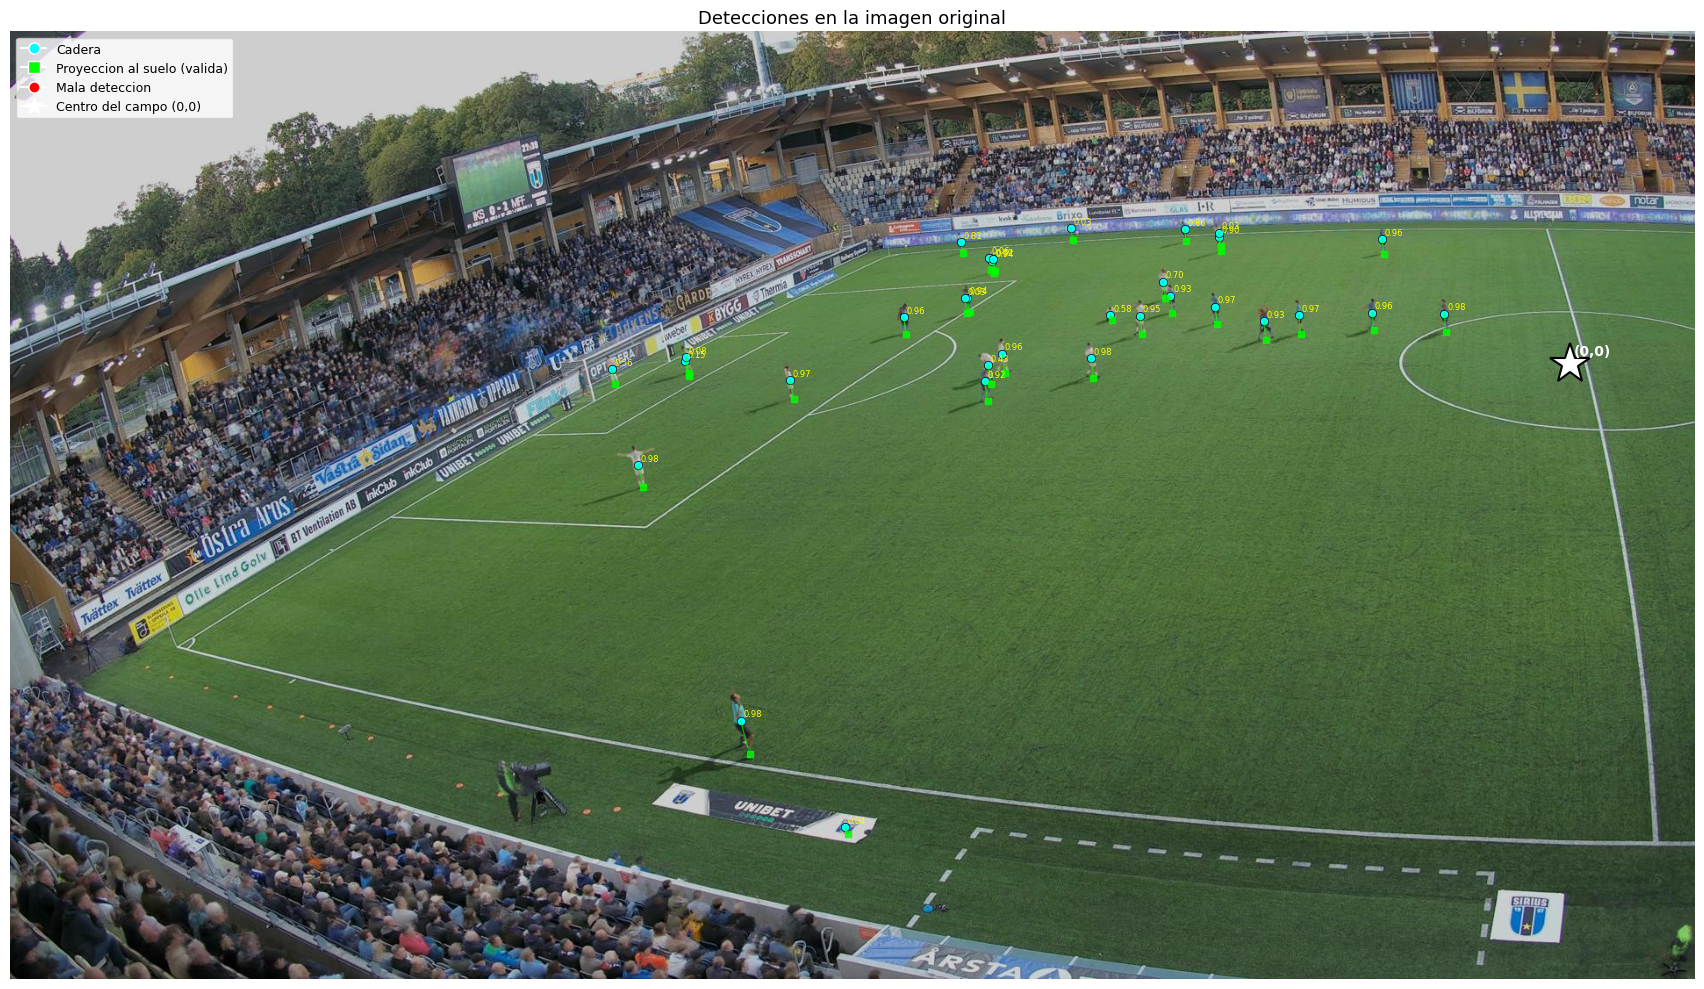

In [31]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from PIL import Image
import numpy as np
from sskit import unnormalize, world_to_image, normalize, image_to_ground

img         = Image.open(img_path)
img_np      = np.array(img)
shape_sskit = (img_np.shape[2], img_np.shape[0], img_np.shape[1])  # (3, h, w)

fig, ax = plt.subplots(figsize=(18, 10))
ax.imshow(img)
ax.set_title('Detecciones en la imagen original', fontsize=13)

for i in range(len(scores)):
    bbox_score = float(scores[i])
    kp = keypoints[i]
    x0, y0 = kp[0][0], kp[0][1]
    x1, y1 = kp[1][0], kp[1][1]
    pie_norm = normalize(kp[1], shape_sskit).float()  # ✅ corregido
    try:
        pos = image_to_ground(cam_mat, dist_p, pie_norm)
        dentro = abs(float(pos[0])) <= 36 and abs(float(pos[1])) <= 55
    except:
        dentro = False
    color_cadera = 'cyan' if dentro else 'red'
    color_suelo  = 'lime' if dentro else 'red'
    ax.plot(x0, y0, 'o', color=color_cadera, markersize=6,
            markeredgecolor='black', markeredgewidth=0.5)
    ax.plot(x1, y1, 's', color=color_suelo, markersize=4, alpha=0.8)
    ax.plot([x0, x1], [y0, y1], '-', color=color_suelo, linewidth=1, alpha=0.6)
    ax.text(x0+3, y0-5, f'{bbox_score:.2f}', color='yellow', fontsize=6)

# Proyectar el centro del campo (0,0,0) a la imagen
try:
    centro_px = unnormalize(world_to_image(cam_mat, dist_p, [0.0, 0.0, 0.0]), shape_sskit)  # ✅ corregido
    ax.plot(centro_px[0], centro_px[1], '*', color='white', markersize=30,
            markeredgecolor='black', markeredgewidth=1.5, label='Centro del campo (0,0)')
    ax.text(centro_px[0]+5, centro_px[1]-10, '(0,0)', color='white', fontsize=10, fontweight='bold')
except Exception as e:
    print(f'Centro fuera de la imagen: {e}')

ax.axis('off')
ax.legend(handles=[
    mlines.Line2D([],[],marker='o',color='w',markerfacecolor='cyan',markersize=8,label='Cadera'),
    mlines.Line2D([],[],marker='s',color='w',markerfacecolor='lime',markersize=8,label='Proyeccion al suelo (valida)'),
    mlines.Line2D([],[],marker='o',color='w',markerfacecolor='red',markersize=8,label='Mala deteccion'),
    mlines.Line2D([],[],marker='*',color='w',markerfacecolor='white',markersize=12,label='Centro del campo (0,0)'),
], loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## Paso 5 — Generar results.json para todas las imagenes

In [32]:
all_results = []
detection_id = 1
SCALE = 2.0  # las anotaciones son 4K pero procesamos FullHD

for img_info in annotations['images']:
    img_path, cam_mat, dist_p, img_np, shape_sskit = prepare_image_inputs(img_info, IMAGES_DIR)

    results_i = inference_topdown(model, img_path)
    result = results_i[0]

    keypoints = result.pred_instances.keypoints
    scores = result.pred_instances.scores
    bboxes = result.pred_instances.bboxes

    for i in range(len(scores)):
        bbox_score = float(scores[i])
        pie_norm = normalize(keypoints[i][1], shape_sskit).float()
        x1, y1, x2, y2 = bboxes[i].tolist()
        bbox_coco = [x1 * SCALE, y1 * SCALE, (x2 - x1) * SCALE, (y2 - y1) * SCALE]

        try:
            pos = image_to_ground(cam_mat, dist_p, pie_norm)
            all_results.append({
                'area': float((x2 - x1) * SCALE * (y2 - y1) * SCALE),
                'category_id': 1,
                'id': detection_id,
                'image_id': img_info['id'],
                'bbox': bbox_coco,
                'position_on_pitch': [float(pos[0]), float(pos[1]), 0.0],
                'score': bbox_score
            })
            detection_id += 1
        except Exception:
            pass

    print(f'  ✅ {os.path.basename(img_path)}: {len(scores)} jugadores')

results_path = f'{WORK_DIR}/results.json'
with open(results_path, 'w') as f:
    json.dump(all_results, f)

print(f'\n✅ results.json guardado con {len(all_results)} detecciones totales')

  ✅ 000000.jpg: 32 jugadores
  ✅ 000001.jpg: 15 jugadores
  ✅ 000002.jpg: 33 jugadores
  ✅ 000003.jpg: 40 jugadores
  ✅ 000004.jpg: 32 jugadores
  ✅ 000005.jpg: 33 jugadores
  ✅ 000006.jpg: 27 jugadores

✅ results.json guardado con 212 detecciones totales


In [33]:
# Comparar bbox predicho vs ground truth para la primera imagen
img_id   = annotations['images'][0]['id']
anns_img = [a for a in annotations['annotations'] if a['image_id'] == img_id]

print('Ground truth bboxes (4K):')
for ann in anns_img[:5]:
    print(f'  {ann["bbox"]}')

print('\nNuestros bboxes (escalados x2):')
with open(results_path) as f:
    res = json.load(f)
res_img = [r for r in res if r['image_id'] == img_id]
for r in res_img[:5]:
    print(f'  {[round(x,1) for x in r["bbox"]]}  score:{r["score"]:.3f}')

Ground truth bboxes (4K):
  [1764, 755, 27, 86]
  [2442, 710, 42, 79]
  [2737, 596, 19, 69]
  [2928, 613, 18, 78]
  [2155, 459, 20, 46]

Nuestros bboxes (escalados x2):
  [1393.6, 945.5, 72.8, 96.1]  score:0.984
  [1639.6, 1503.0, 58.7, 151.8]  score:0.981
  [3258.9, 608.3, 20.9, 77.5]  score:0.977
  [2442.5, 710.5, 36.7, 78.9]  score:0.977
  [2735.2, 595.0, 22.6, 72.3]  score:0.972


In [34]:
# Filtrar solo detecciones con score alto
SCORE_THR = 0.5

all_results_filtered = [r for r in res if r['score'] >= SCORE_THR]
print(f'Detecciones con score >= {SCORE_THR}: {len(all_results_filtered)}')

results_path_filtered = f'{WORK_DIR}/results_filtered.json'
with open(results_path_filtered, 'w') as f:
    json.dump(all_results_filtered, f)

Detecciones con score >= 0.5: 118


## Paso 6 — Evaluar con mAP-LocSim

In [35]:
from xtcocotools.coco import COCO
from sskit.coco import LocSimCOCOeval

ann_eval_path = ANN_JSON_PATH if 'ANN_JSON_PATH' in globals() else ANN_PATH

coco_gt   = COCO(ann_eval_path)
coco_dt   = coco_gt.loadRes(results_path)
coco_eval = LocSimCOCOeval(coco_gt, coco_dt, 'bbox')
coco_eval.params.useSegm = None

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

print(f'\n🏆 mAP-LocSim baseline: {coco_eval.stats[0]:.4f}')
print(f'📐 Score threshold:     {coco_eval.stats[15]:.4f}')

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] =  0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] =  0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] =  0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] =  0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] =  0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] =  0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] =  0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] =  0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all |